In [33]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
from pathlib import Path
import cv2

def find_project_root(start: Path) -> Path:
    start = start.resolve()
    
    for candidate in [start, *start.parents]:
        if (candidate / "data").exists():
            return candidate
    raise FileNotFoundError("Could not find project root containing a 'data' folder.")

project_root = find_project_root(Path.cwd())
labels_path = project_root / "data" / "trainLabels.csv"

train_labels = pd.read_csv(labels_path)

train_labels.head(5)

,id,label
0,1,frog
1,2,truck
2,3,truck
3,4,deer
4,5,automobile


C:\Users\dparh\AppData\Local\Temp\ipykernel_13836\3738687120.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=label_counts, x='label', y='count', palette='Set2')


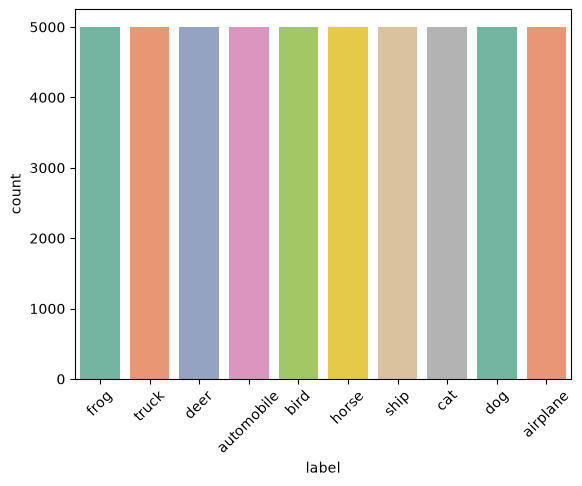

Frequency of each class

        label  count  percentage
0        frog   5000        10.0
1       truck   5000        10.0
2        deer   5000        10.0
3  automobile   5000        10.0
4        bird   5000        10.0
5       horse   5000        10.0
6        ship   5000        10.0
7         cat   5000        10.0
8         dog   5000        10.0
9    airplane   5000        10.0


In [32]:
# Labels distribution
label_counts = train_labels['label'].value_counts().reset_index()
label_counts.columns = ['label', 'count']
sns.barplot(data=label_counts, x='label', y='count', palette='Set2')
plt.xticks(rotation=45)
plt.show()

# percentage-wise
print(f"Frequency of each class\n")
label_counts['percentage'] = (label_counts['count'] / label_counts['count'].sum()) * 100
print(label_counts)

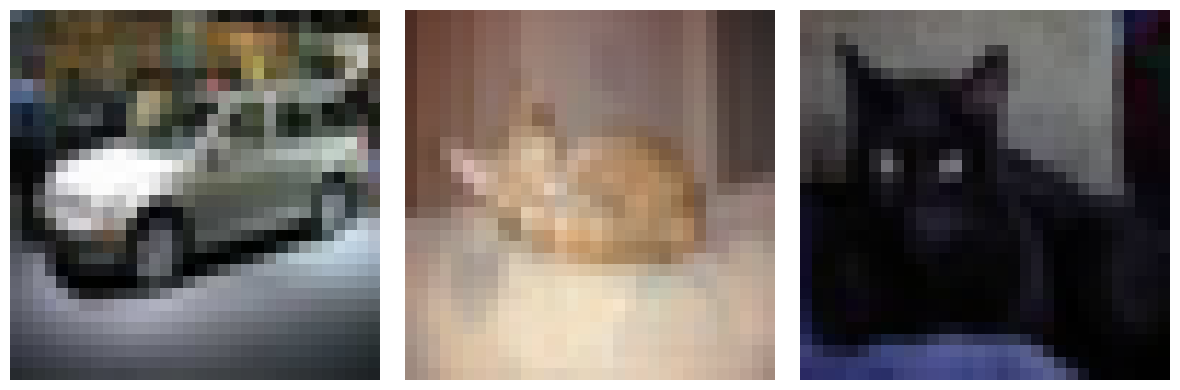

Height: 32 | Width: 32 | Channels: 3
Height: 32 | Width: 32 | Channels: 3
Height: 32 | Width: 32 | Channels: 3


In [ ]:
# show a few images
import random
imgs_dir = Path(project_root / "data" / "train" / "train")

image_files = [f for f in imgs_dir.iterdir() if f.suffix.lower() in ['.png', '.jpg', '.jpeg']]
rnd_imgs = random.sample(image_files, k=3)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for idx, img_path in enumerate(rnd_imgs):
    img = cv2.imread(str(img_path))
    if img is not None:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[idx].imshow(img)
    else:
        print(f"Could not read image: {img_path}")
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

# get size of images
for image in rnd_imgs:
    image = cv2.imread(image)
    height, width, chan = image.shape
    print(f"Height: {height} | Width: {width} | Channels: {chan}")
    # (32,32,3) images, light work